# Análisis Exploratorio de Datos (EDA)

### Correlaciones definitivas

In [1]:
#Correlacion de las columnas con el precio por noche
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go


df = pd.read_csv('../data/listingV5.csv')

correlacion = df.corr(numeric_only=True)['price'].drop('price').sort_values()

colors = ['#ef4444' if v < 0 else '#3b82f6' for v in correlacion.values]

fig = go.Figure(go.Bar(
    x=correlacion.values,
    y=correlacion.index,
    orientation='h',
    marker_color=colors,
    text=[f"{v:.3f}" for v in correlacion.values],
    textposition='outside'
))

fig.update_layout(title="Correlación variables numéricas con Price", height=1400)
fig.update_xaxes(title_text="Correlación r")
fig.update_yaxes(title_text="Variable")
fig.add_vline(x=0.1, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=-0.1, line_dash="dash", line_color="gray", opacity=0.5)
fig.show()

In [2]:
from scipy import stats
import pandas as pd

cols_categoricas = df.select_dtypes(include='object').columns.tolist()

resultados_anova = []

for col in cols_categoricas:
    grupos = [df[df[col] == cat]['price'].dropna()
            for cat in df[col].dropna().unique()
            if len(df[df[col] == cat]['price'].dropna()) > 1]  # evitar grupos vacíos
    
    if len(grupos) > 1:  # ANOVA necesita al menos 2 grupos
        f_stat, p_valor = stats.f_oneway(*grupos)
        resultados_anova.append({'columna': col, 'p_valor': round(p_valor, 6)})
    else:
        resultados_anova.append({'columna': col, 'p_valor': None})

resultados_anova_df = pd.DataFrame(resultados_anova).sort_values('p_valor')
print(resultados_anova_df.to_string())



                  columna  p_valor
1  neighbourhood_cleansed  0.00000
2           property_type  0.00000
3               room_type  0.00000
0      host_response_time  0.56752


C:\Users\david\AppData\Local\Temp\ipykernel_24860\714601580.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price', data=df_vis, ax=axes[0,1], palette='Set2')


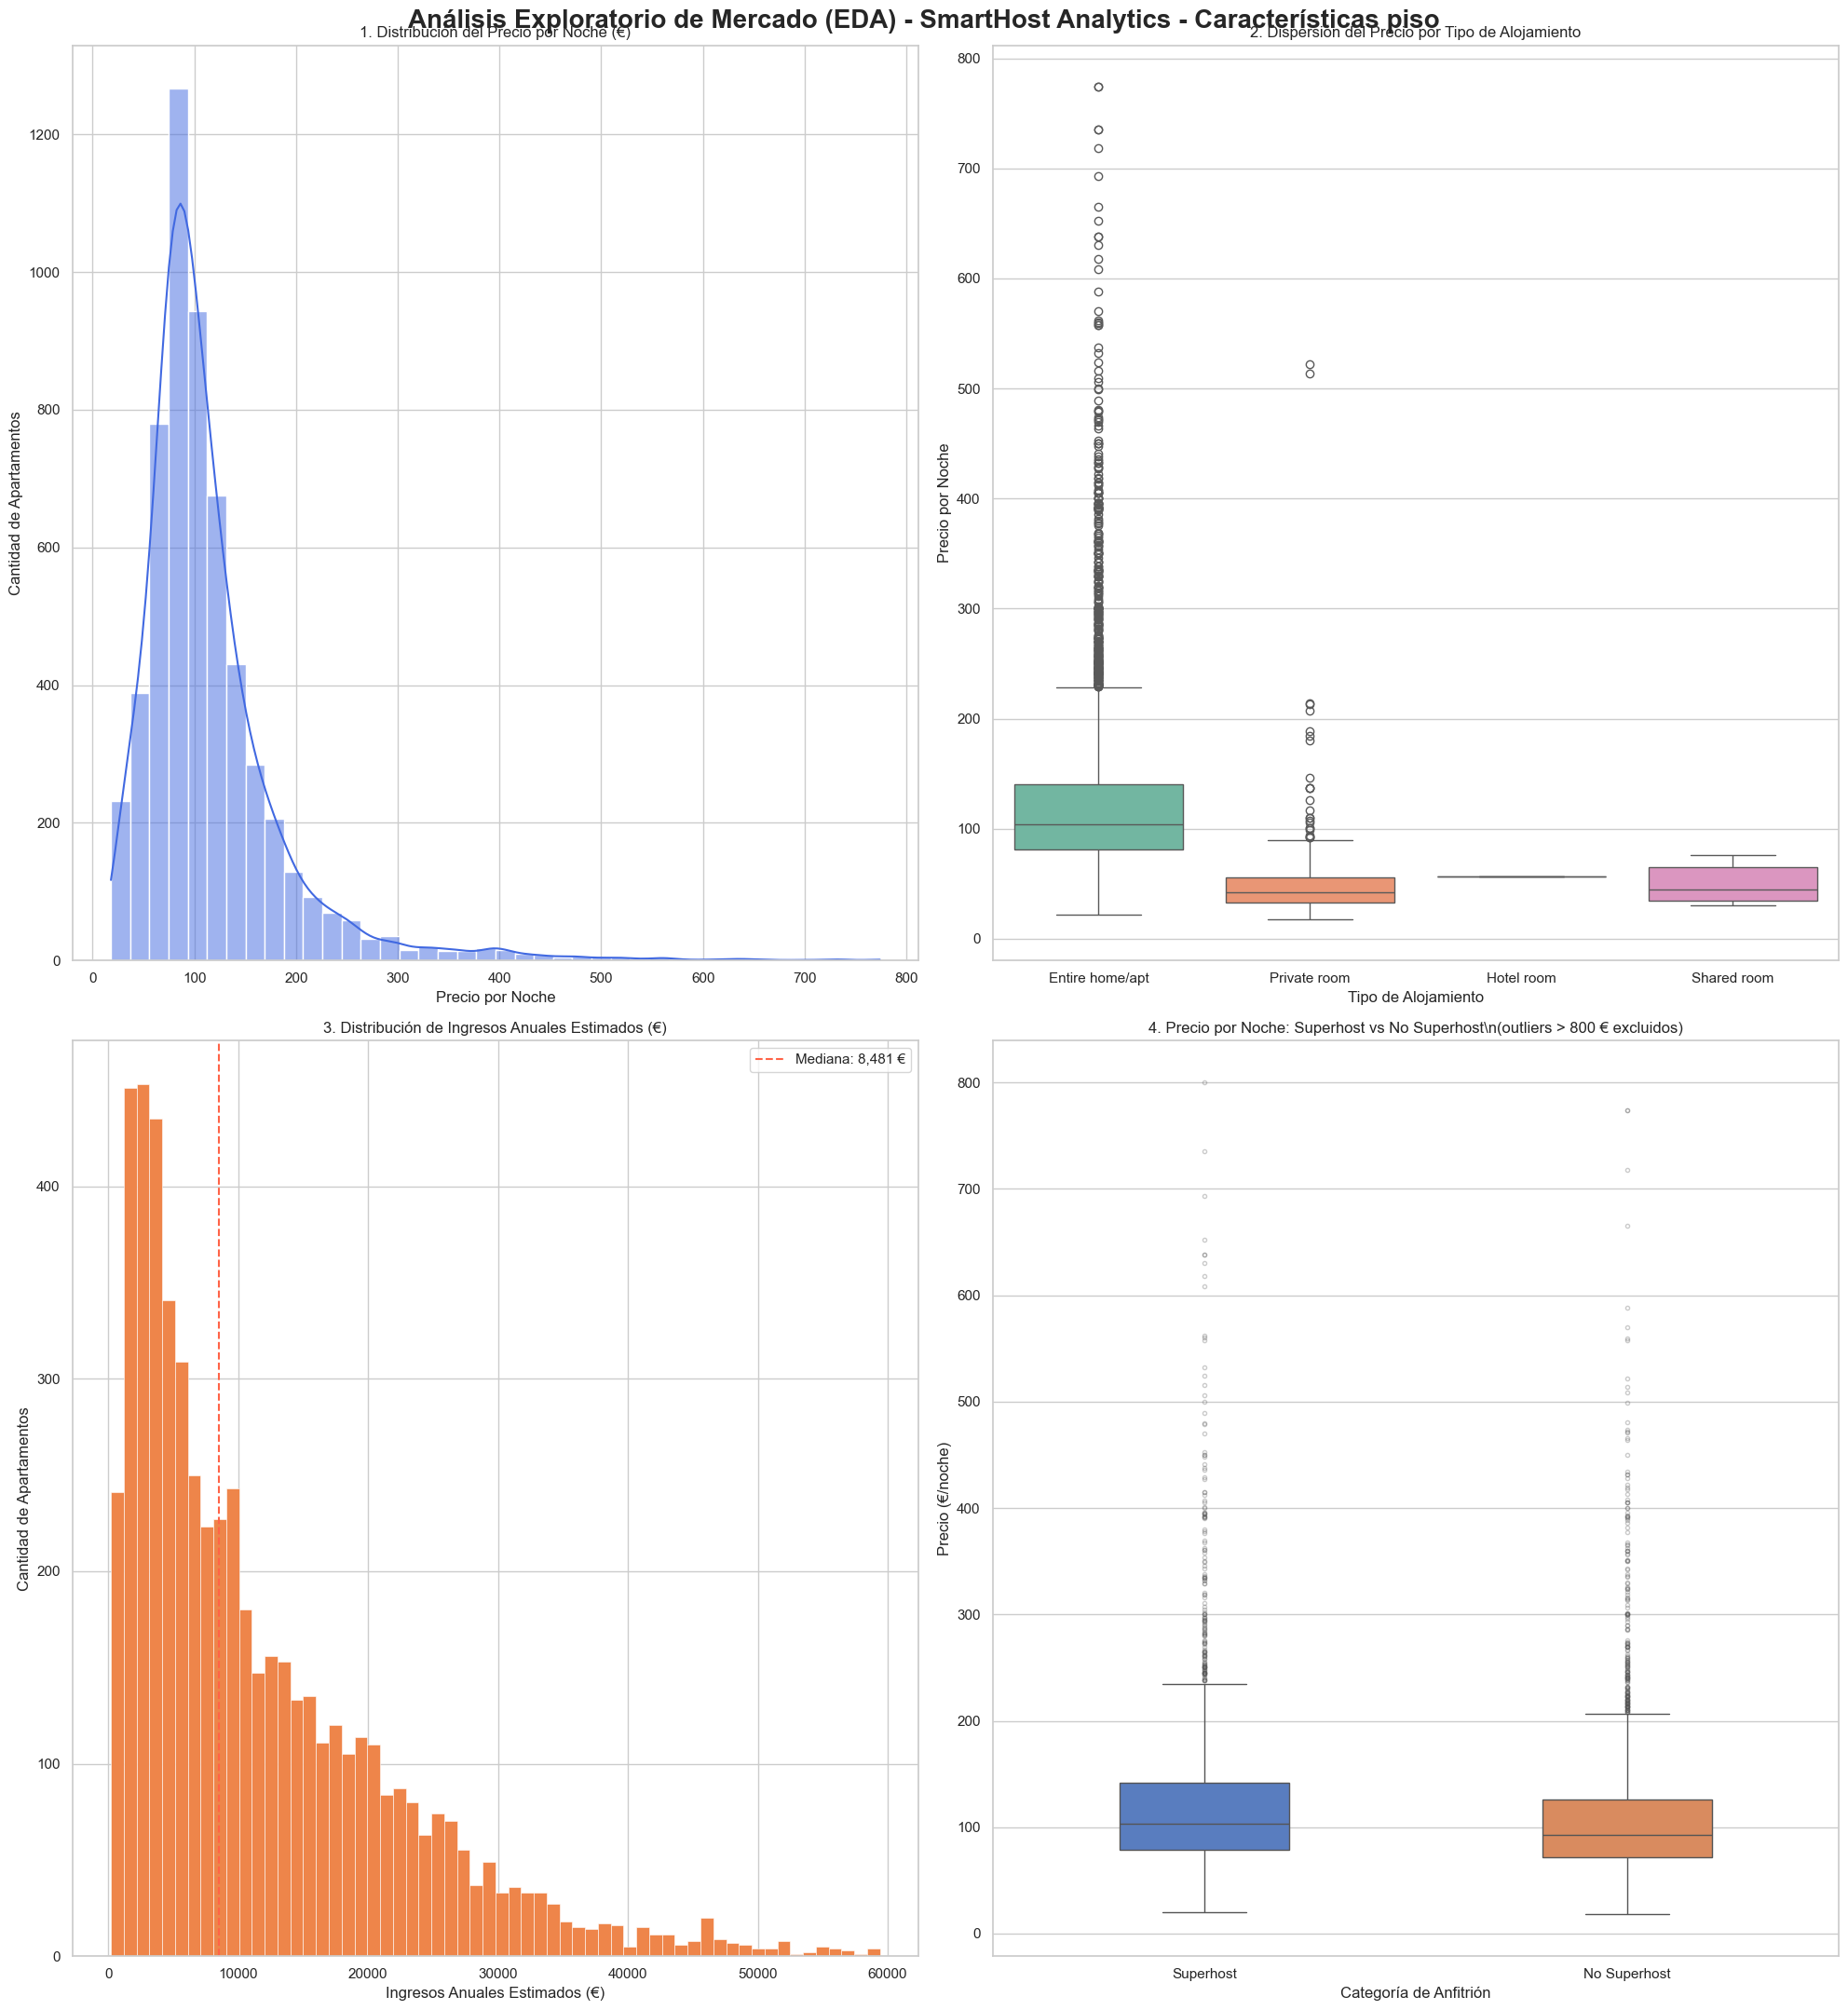

\n--- Estadísticas comparativas Superhost vs No Superhost ---
               count   mean   std   min   25%    50%    75%    max
sh_label                                                          
No Superhost  3314.0  109.4  68.0  18.0  72.0   93.0  126.0  774.0
Superhost     2289.0  123.4  80.1  20.0  79.0  103.0  142.0  800.0


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Configuración de estilo profesional para la Memoria
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})


# --- PREPARACIÓN PARA VISUALIZACIÓN ---
# El precio suele tener "outliers" (pisos a 3.000€/noche que aplastan la gráfica).
# Para ver bien las tendencias en el EDA, filtramos los precios normales (ej. < 800€)
df_vis = df[df['price'] < 800]
# Crear el lienzo (Dashboard de 5 gráficas)
fig, axes = plt.subplots(2, 2, figsize=(20, 22))
fig.suptitle('Análisis Exploratorio de Mercado (EDA) - SmartHost Analytics - Características piso', fontsize=20, fontweight='bold', y=0.98)

# =========================================================
# GRÁFICA 1: Histograma - Distribución de nuestro Target
# =========================================================
sns.histplot(df_vis['price'], bins=40, kde=True, ax=axes[0,0], color='royalblue')
axes[0,0].set_title('1. Distribución del Precio por Noche (€)')
axes[0,0].set_xlabel('Precio por Noche')
axes[0,0].set_ylabel('Cantidad de Apartamentos')

# =========================================================
# GRÁFICA 2: Boxplot - Precio según Tipo de Habitación
# =========================================================
sns.boxplot(x='room_type', y='price', data=df_vis, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('2. Dispersión del Precio por Tipo de Alojamiento')
axes[0,1].set_xlabel('Tipo de Alojamiento')
axes[0,1].set_ylabel('Precio por Noche')

# =========================================================
# GRÁFICA 3: Histograma - Distribución de Ingresos Anuales
# =========================================================
rev_clip = df["estimated_revenue_l365d"][df["estimated_revenue_l365d"].between(1, 60000)]
axes[1, 0].hist(rev_clip, bins=60, edgecolor="white", linewidth=0.4,
                color=sns.color_palette("muted")[1])
axes[1, 0].axvline(rev_clip.median(), color="tomato", linestyle="--", linewidth=1.5,
                    label=f"Mediana: {rev_clip.median():,.0f} €")
axes[1, 0].set_title('3. Distribución de Ingresos Anuales Estimados (€)')
axes[1, 0].set_xlabel('Ingresos Anuales Estimados (€)')
axes[1, 0].set_ylabel('Cantidad de Apartamentos')
axes[1, 0].legend()

# =========================================================
# GRÁFICA 4: Boxplot - Precio Superhost vs No Superhost
# =========================================================
df_sh = df[df["price"].between(10, 800)].copy()
df_sh["sh_label"] = df_sh["host_is_superhost"].map({1.0: "Superhost", 0.0: "No Superhost"})
df_sh = df_sh.dropna(subset=["sh_label"])
sns.boxplot(data=df_sh, x="sh_label", y="price",
            hue="sh_label", palette="muted", width=0.4, legend=False,
            flierprops=dict(marker=".", alpha=0.3), ax=axes[1, 1])
axes[1, 1].set_title('4. Precio por Noche: Superhost vs No Superhost\\n(outliers > 800 € excluidos)')
axes[1, 1].set_xlabel('Categoría de Anfitrión')
axes[1, 1].set_ylabel('Precio (€/noche)')

plt.tight_layout()
# plt.savefig('../data/EDA_SmartHost.png', dpi=300)
plt.show()

# Estadísticas comparativas Superhost
print("\\n--- Estadísticas comparativas Superhost vs No Superhost ---")
print(df_sh.groupby("sh_label")["price"].describe().round(1))


# Guardamos la imagen en alta resolución para tu Memoria
#plt.savefig('../data/EDA_SmartHost.png', dpi=300)
plt.show()

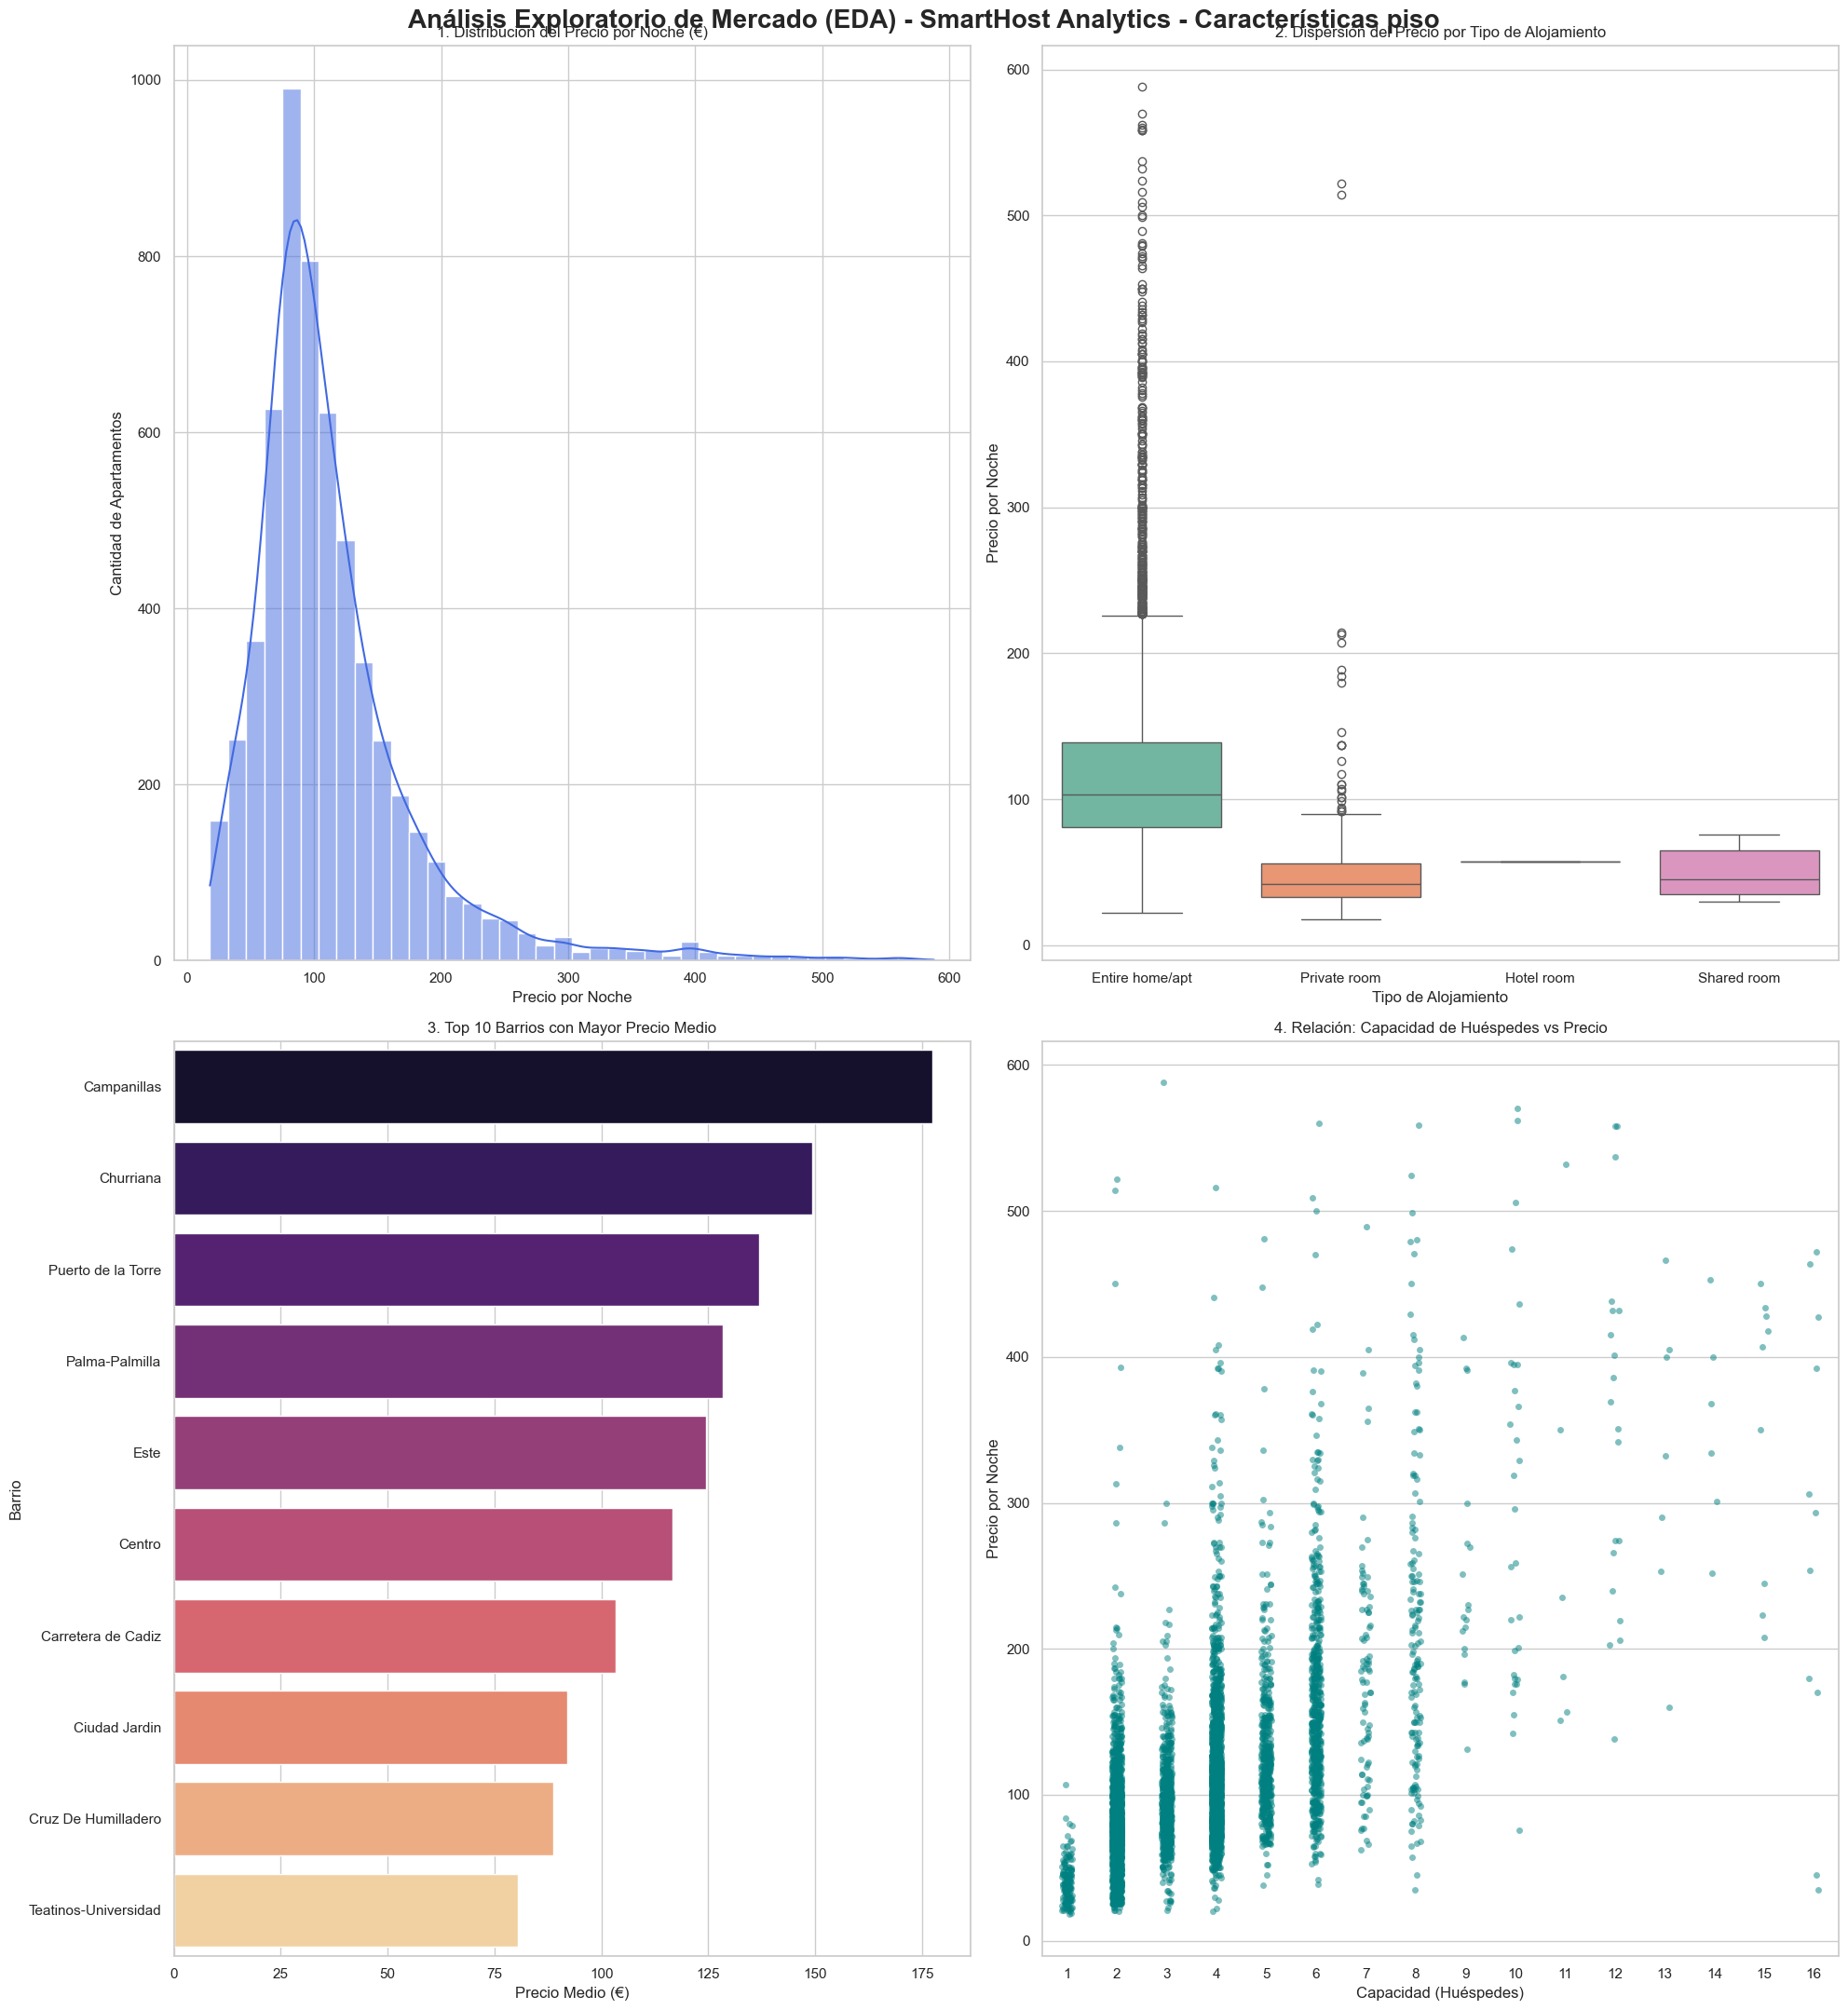

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# Filtrar outliers para visualización
df_vis = df[df['price'] < 600]

# Crear el lienzo
fig, axes = plt.subplots(2, 2, figsize=(20, 22))
fig.suptitle('Análisis Exploratorio de Mercado (EDA) - Características piso - SmartHost Analytics',
            fontsize=20, fontweight='bold', y=0.98)

# =========================================================
# GRÁFICA 1: Histograma - Distribución del Target
# =========================================================
sns.histplot(df_vis['price'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('1. Distribución del Precio por Noche (€)')
axes[0, 0].set_xlabel('Precio por Noche')
axes[0, 0].set_ylabel('Cantidad de Apartamentos')

# =========================================================
# GRÁFICA 2: Boxplot - Precio según Tipo de Habitación
# =========================================================
sns.boxplot(x='room_type', y='price', data=df_vis,
            hue='room_type', palette='Set2', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('2. Dispersión del Precio por Tipo de Alojamiento')
axes[0, 1].set_xlabel('Tipo de Alojamiento')
axes[0, 1].set_ylabel('Precio por Noche')

# =========================================================
# GRÁFICA 3: Barras - Top 10 Barrios Más Caros
# =========================================================
top_barrios = (df_vis.groupby('neighbourhood_cleansed')['price']
                .mean().sort_values(ascending=False).head(10).reset_index())
sns.barplot(x='price', y='neighbourhood_cleansed', data=top_barrios,
            hue='neighbourhood_cleansed', palette='magma', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('3. Top 10 Barrios con Mayor Precio Medio')
axes[1, 0].set_xlabel('Precio Medio (€)')
axes[1, 0].set_ylabel('Barrio')

# =========================================================
# GRÁFICA 4: Scatter - Capacidad vs Precio
# =========================================================
sns.stripplot(x='accommodates', y='price', data=df_vis,
                alpha=0.5, jitter=True, color='teal', ax=axes[1, 1])
axes[1, 1].set_title('4. Relación: Capacidad de Huéspedes vs Precio')
axes[1, 1].set_xlabel('Capacidad (Huéspedes)')
axes[1, 1].set_ylabel('Precio por Noche')

plt.tight_layout()
# plt.savefig('../data/EDA_SmartHost.png', dpi=300)
plt.show()

#### Breve análisis

1. Histograma precio vs cantidad apartamentos: Se obrserva claramente que la mayoría de apartamentos se encuentran entre los 50 y 140€ la noche aproximadamente.
2. Boxplots de precio por tipo apartamento: Este gráfico nos da a entender como un apartamento entero siempre tendrá un precio claramento superior a un apartamento compartido o una habitación privada (Que suelen tener estancias compartidas también).
3. Histograma Barrios mas caros: Este hisgrama de barras nos muestra el top 10 de barrios ordenados en función a su precio medio por noche.
4. Gráfico dispersión capacidad alojamiento vs precio: A mayor capacidad de huéspedes vemos como el precio mínimo por noche suele ser cada vez mayor. También podemos observar como la mayoría de apartamentos se concentran en la capacidad para 1-6 huéspedes.

C:\Users\david\AppData\Local\Temp\ipykernel_24860\1272777615.py:103: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


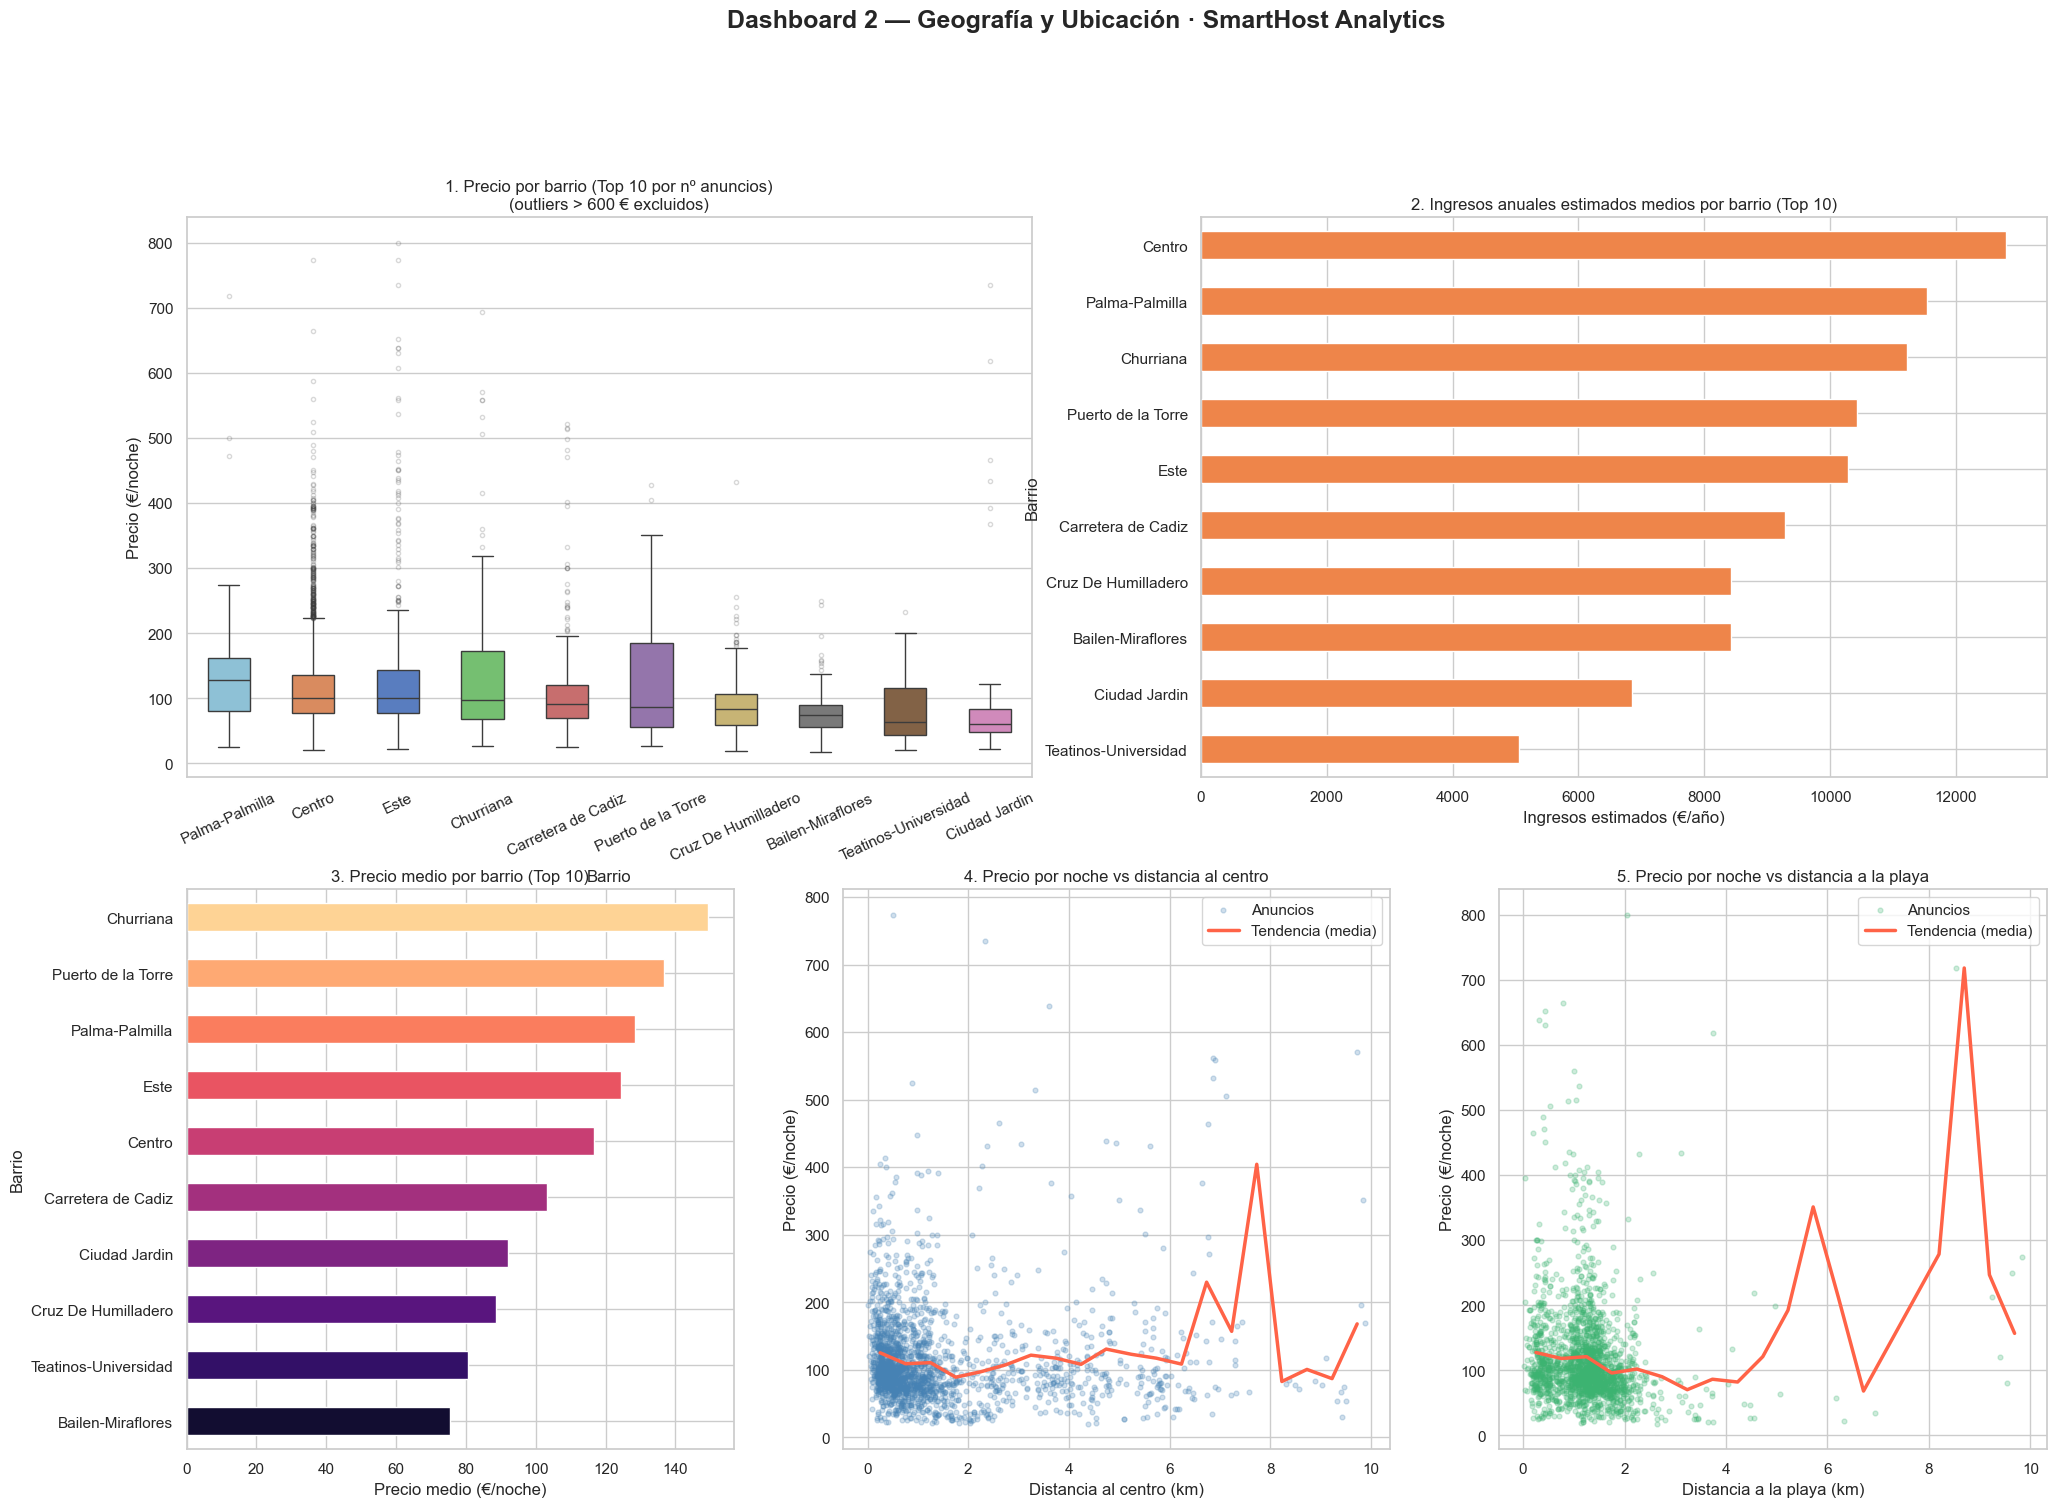

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# ── Preparación de datos ──────────────────────────────────────────────────────
top10 = df["neighbourhood_cleansed"].value_counts().head(10).index
df_bar = df[df["neighbourhood_cleansed"].isin(top10) & df["price"].between(10, 800)].copy()
order_b = (df_bar.groupby("neighbourhood_cleansed")["price"]
            .median().sort_values(ascending=False).index.tolist())

df_sc = df[df["price"].between(10, 800) & df["distancia_centro_km"].between(0, 10)].copy()
df_pl = df[df["price"].between(10, 800) & df["distancia_playa_km"].between(0, 10)].copy()
sample    = df_sc.sample(2000, random_state=42)
sample_pl = df_pl.sample(min(2000, len(df_pl)), random_state=42)

# ── Lienzo: fila superior 2 cols, fila inferior 3 cols ───────────────────────
fig = plt.figure(figsize=(24, 16))
fig.suptitle('Dashboard 2 — Geografía y Ubicación · SmartHost Analytics',
            fontsize=18, fontweight='bold', y=1.01)

ax1 = fig.add_subplot(2, 2, 1)   # Boxplot barrios
ax2 = fig.add_subplot(2, 2, 2)   # Ingresos barrios
ax3 = fig.add_subplot(2, 3, 4)   # Precio medio barrios
ax4 = fig.add_subplot(2, 3, 5)   # Scatter distancia centro
ax5 = fig.add_subplot(2, 3, 6)   # Scatter distancia playa

# =========================================================
# GRÁFICA 1: Boxplot precio por barrio (Top 10)
# =========================================================
sns.boxplot(data=df_bar, x="neighbourhood_cleansed", y="price", order=order_b,
            hue="neighbourhood_cleansed", palette="muted", width=0.5,
            flierprops=dict(marker=".", alpha=0.2), legend=False, ax=ax1)
ax1.set_title("1. Precio por barrio (Top 10 por nº anuncios)\n(outliers > 600 € excluidos)")
ax1.set_xlabel("Barrio")
ax1.set_ylabel("Precio (€/noche)")
ax1.tick_params(axis="x", rotation=25)

# =========================================================
# GRÁFICA 2: Ingresos anuales medios por barrio (Top 10)
# =========================================================
rev_barrio = (
    df[df["neighbourhood_cleansed"].isin(top10) & df["estimated_revenue_l365d"].between(1, 60000)]
    .groupby("neighbourhood_cleansed")["estimated_revenue_l365d"]
    .mean()
    .sort_values(ascending=True)
)
rev_barrio.plot(kind="barh", ax=ax2,
                color=sns.color_palette("muted")[1], edgecolor="white")
ax2.set_title("2. Ingresos anuales estimados medios por barrio (Top 10)")
ax2.set_xlabel("Ingresos estimados (€/año)")
ax2.set_ylabel("Barrio")

# =========================================================
# GRÁFICA 3: Precio medio por barrio (barras horizontales)
# =========================================================
top_precio = (
    df[df["neighbourhood_cleansed"].isin(top10) & df["price"].between(10, 600)]
    .groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=True)
)
top_precio.plot(kind="barh", ax=ax3,
                color=sns.color_palette("magma", len(top_precio)), edgecolor="white")
ax3.set_title("3. Precio medio por barrio (Top 10)")
ax3.set_xlabel("Precio medio (€/noche)")
ax3.set_ylabel("Barrio")

# =========================================================
# GRÁFICA 4: Scatter precio vs distancia al centro
# =========================================================
ax4.scatter(sample["distancia_centro_km"], sample["price"],
            alpha=0.25, s=12, color="steelblue", label="Anuncios")
bins_c = pd.cut(df_sc["distancia_centro_km"], bins=20)
trend_c = df_sc.groupby(bins_c, observed=True)["price"].mean().reset_index()
trend_c["x"] = trend_c["distancia_centro_km"].apply(lambda b: b.mid)
ax4.plot(trend_c["x"], trend_c["price"],
        color="tomato", linewidth=2.5, label="Tendencia (media)")
ax4.set_title("4. Precio por noche vs distancia al centro")
ax4.set_xlabel("Distancia al centro (km)")
ax4.set_ylabel("Precio (€/noche)")
ax4.legend()

# =========================================================
# GRÁFICA 5: Scatter precio vs distancia a la playa
# =========================================================
ax5.scatter(sample_pl["distancia_playa_km"], sample_pl["price"],
            alpha=0.25, s=12, color="mediumseagreen", label="Anuncios")
bins_p = pd.cut(df_pl["distancia_playa_km"], bins=20)
trend_p = df_pl.groupby(bins_p, observed=True)["price"].mean().reset_index()
trend_p["x"] = trend_p["distancia_playa_km"].apply(lambda b: b.mid)
ax5.plot(trend_p["x"], trend_p["price"],
        color="tomato", linewidth=2.5, label="Tendencia (media)")
ax5.set_title("5. Precio por noche vs distancia a la playa")
ax5.set_xlabel("Distancia a la playa (km)")
ax5.set_ylabel("Precio (€/noche)")
ax5.legend()

plt.tight_layout()
plt.savefig('../data/dashboard2_geografia.png', dpi=300)
plt.show()

In [24]:
import folium
from folium.plugins import HeatMap
import pandas as pd
import json

# ── 1. Cargar el GeoJSON desde archivo local ──────────────────────────────────
with open("../data/neighbourhoods.geojson", "r", encoding="utf-8") as f:
    neighbourhoods_geojson = json.load(f)

print(f"GeoJSON cargado: {len(neighbourhoods_geojson['features'])} barrios")
# ── 2. Preparación de datos ───────────────────────────────────────────────────
df_map = df[df["price"].between(10, 400)].dropna(subset=["latitude", "longitude", "price"]).copy()
df_map["price_norm"] = (df_map["price"] - df_map["price"].min()) / \
                        (df_map["price"].max() - df_map["price"].min())
heat_data = df_map[["latitude", "longitude", "price_norm"]].values.tolist()

# ── 3. Crear el mapa base centrado en Málaga ──────────────────────────────────
mapa = folium.Map(
    location=[df_map["latitude"].mean(), df_map["longitude"].mean()],
    zoom_start=13,
    tiles="CartoDB positron"
)

# ── 4. Añadir el contorno del área estudiada (barrios Inside Airbnb) ──────────
folium.GeoJson(
    neighbourhoods_geojson,
    name="Barrios Inside Airbnb",
    style_function=lambda feature: {
        "fillColor": "#4a90d9",
        "color": "#1a5fa8",       # borde azul oscuro
        "weight": 1.5,
        "fillOpacity": 0.04,      # casi transparente para no tapar el heatmap
        "dashArray": "4 4"        # línea discontinua → indica "área de estudio"
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["neighbourhood"],
        aliases=["Barrio:"],
        style="font-family: Arial; font-size: 12px;"
    )
).add_to(mapa)

# ── 5. Añadir capa de calor de precios ───────────────────────────────────────
HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=15,
    blur=12,
    max_zoom=16,
    gradient={
        0.2: "#313695",
        0.4: "#74add1",
        0.6: "#fee090",
        0.8: "#f46d43",
        1.0: "#a50026"
    }
).add_to(mapa)

# ── 6. Control de capas (activar/desactivar heatmap o barrios) ────────────────
folium.LayerControl().add_to(mapa)

# ── 7. Leyenda ────────────────────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background: white; padding: 14px 18px; border-radius: 8px;
            box-shadow: 2px 2px 8px rgba(0,0,0,0.3); font-family: Arial; font-size: 13px;">
    <b>Precio por noche (€)</b><br>
    <div style="display:flex; align-items:center; margin-top:8px;">
        <div style="width:160px; height:14px;
                    background: linear-gradient(to right, #313695, #74add1, #fee090, #f46d43, #a50026);
                    border-radius:3px; margin-right:8px;"></div>
    </div>
    <div style="display:flex; justify-content:space-between; width:160px;
                font-size:11px; margin-top:3px;">
        <span>10 €</span><span>→</span><span>400 €</span>
    </div>
    <hr style="margin:10px 0; border-color:#ddd;">
    <div style="display:flex; align-items:center; gap:8px; font-size:12px;">
        <div style="width:28px; height:2px; border-top: 2px dashed #1a5fa8;"></div>
        <span>Área de estudio (Inside Airbnb)</span>
    </div>
</div>
"""
mapa.get_root().html.add_child(folium.Element(legend_html))

# ── 8. Mostrar en Jupyter y guardar ──────────────────────────────────────────
display(mapa)
mapa.save("../data/heatmap_precios_malaga.html")
print("Mapa guardado en ../data/heatmap_precios_malaga.html")

GeoJSON cargado: 11 barrios


Mapa guardado en ../data/heatmap_precios_malaga.html


## 🔍 Análisis e Hipótesis — Dashboard 2: Geografía y Ubicación

---

### 1. Concentración geográfica de la oferta

El mapa de calor revela que **la gran mayoría de los anuncios se concentran en el núcleo urbano de Málaga**, especialmente en el triángulo formado por el Centro histórico, el frente litoral (Malagueta - El Palo) y el corredor hacia Churriana. Las zonas periféricas (norte montañoso, municipios del interior) tienen densidad mínima.

> **Hipótesis:** La oferta Airbnb en Málaga responde al patrón clásico de turismo urbano-costero. El visitante tipo busca proximidad al centro histórico (Alcazaba, Catedral, Calle Larios) y/o al mar. Esto implica que **la ubicación es, a priori, la variable con mayor poder predictivo** sobre el precio.

---

### 2. La paradoja del Centro: precio medio moderado con alta dispersión

El boxplot por barrios muestra que **Centro no lidera el ranking de precio medio** — es superado por Palma-Palmilla, Puerto de la Torre, Churriana o Este. Sin embargo, es el barrio con **mayor número de outliers por encima** (precios superiores a 300-400 €/noche).

Esto genera una distribución muy asimétrica con mediana contenida pero cola derecha larga, lo que explica su posición intermedia en el gráfico de precio medio.

> **Hipótesis:** En el Centro coexisten dos segmentos muy distintos:
> - **Segmento bajo/medio:** habitaciones privadas, estudios pequeños y pisos compartidos que compiten por precio y arrastran la mediana hacia abajo.
> - **Segmento alto:** apartamentos de lujo, áticos y propiedades premium en ubicaciones prime (junto a la Catedral, el Puerto) que generan los outliers superiores.
>
> La red neuronal deberá aprender a separar estos dos sub-mercados dentro del mismo barrio — esto justifica incluir variables como `room_type`, `accommodates` y `amenities_score` junto a la variable geográfica.

---

### 3. Barrios periféricos con precio medio alto: el efecto villa/chalet

Barrios como **Churriana, Puerto de la Torre o Palma-Palmilla** tienen precios medios superiores al Centro a pesar de estar más alejados del núcleo turístico. Esto se confirma también en los scatter plots de distancia: a partir de los 6-7 km del centro o la playa, la tendencia media de precio repunta significativamente.

> **Hipótesis:** Los alojamientos más alejados no son pisos turísticos estándar, sino **villas, chalets y casas rurales con alta capacidad** (8-12 huéspedes, piscina, jardín) que justifican un precio por noche elevado. El precio se divide entre más personas, pero el valor absoluto por noche es alto.
>
> Esto sugiere que la variable `price_per_person` y `accommodates` serán especialmente relevantes para la red en estos rangos de distancia. El modelo no debería interpretar "lejos del centro = barato" de forma lineal.

---

### 4. Distancia al centro vs. precio: relación no lineal

El scatter de `distancia_centro_km` muestra una **tendencia en forma de U asimétrica**: el precio medio baja levemente al alejarse del centro en los primeros 4-5 km (zona residencial estándar), pero **repunta con fuerza a partir de los 6-7 km**, coincidiendo con la transición hacia municipios periurbanos con alojamientos de mayor tamaño.

> **Implicación para el modelo:** Una regresión lineal simple sobre `distancia_centro_km` capturaría mal esta relación. Las **redes neuronales con capas ocultas** pueden aprender esta no-linealidad de forma natural, lo que refuerza la elección de arquitectura del proyecto. Alternativamente, podría plantearse una transformación polinómica de esta feature como baseline.

---

### 5. Distancia a la playa: patrón similar con matiz costero

La relación `distancia_playa_km` vs. precio presenta un patrón análogo al del centro, con la salvedad de que **los precios más altos en proximidad a la playa** (0-1 km) son más consistentes y con menos ruido. A mayor distancia, el efecto villa vuelve a aparecer en el extremo derecho.

> **Hipótesis:** La variable `distancia_playa_km` aporta información **complementaria y no redundante** respecto a `distancia_centro_km`, ya que captura el valor del turismo de sol y playa que no está correlacionado con el turismo cultural del centro. Incluir ambas en el modelo está justificado.

---

### 6. Ingresos anuales vs. precio: Centro lidera en rentabilidad real

Aunque el precio medio del Centro no es el más alto, **sí es el barrio con mayores ingresos anuales estimados** (gráfico 2). Esto indica que los apartamentos del centro tienen una **tasa de ocupación significativamente superior** al resto.

> **Hipótesis:** El precio por noche y la rentabilidad anual son variables objetivo con dinámicas diferentes. Un piso en Churriana puede cobrar más por noche, pero permanece vacío más días. Esto justifica que SmartHost Analytics prediga **ambas variables** (`price` y `estimated_revenue_l365d`) en lugar de solo el precio.

---

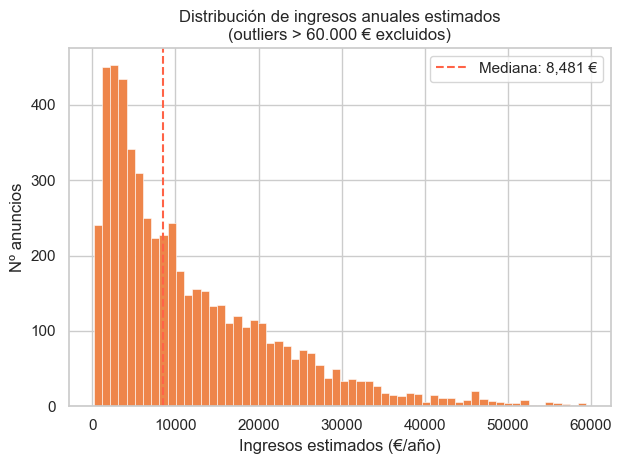

In [5]:
fig, ax = plt.subplots()

rev_clip = df["estimated_revenue_l365d"][df["estimated_revenue_l365d"].between(1, 60000)]
ax.hist(rev_clip, bins=60, edgecolor="white", linewidth=0.4, color=sns.color_palette("muted")[1])

ax.set_title("Distribución de ingresos anuales estimados\n(outliers > 60.000 € excluidos)")
ax.set_xlabel("Ingresos estimados (€/año)")
ax.set_ylabel("Nº anuncios")
ax.axvline(rev_clip.median(), color="tomato", linestyle="--", linewidth=1.5,
            label=f"Mediana: {rev_clip.median():,.0f} €")
ax.legend()
plt.tight_layout()
plt.show()

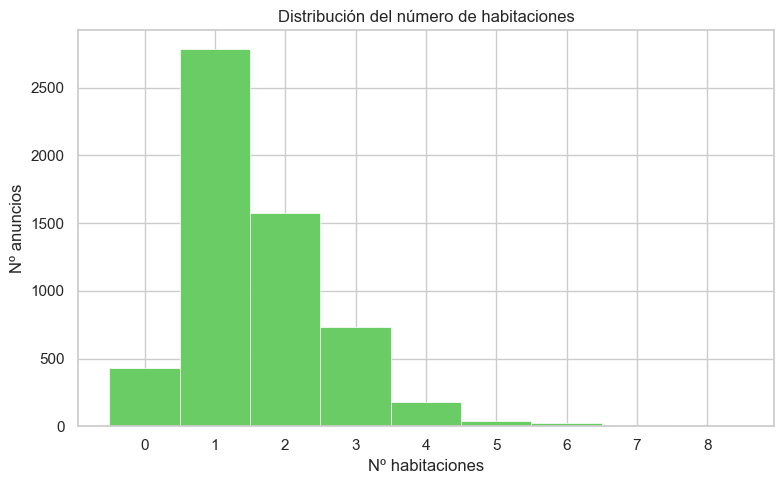

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

beds_clip = df["bedrooms"].dropna()
beds_clip = beds_clip[beds_clip <= 8]
ax.hist(beds_clip, bins=range(0, 10), edgecolor="white", linewidth=0.5,
        align="left", color=sns.color_palette("muted")[2])

ax.set_title("Distribución del número de habitaciones")
ax.set_xlabel("Nº habitaciones")
ax.set_ylabel("Nº anuncios")
ax.set_xticks(range(0, 9))
plt.tight_layout()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_24860\2732301580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bar, x="neighbourhood_cleansed", y="price", order=order_b,


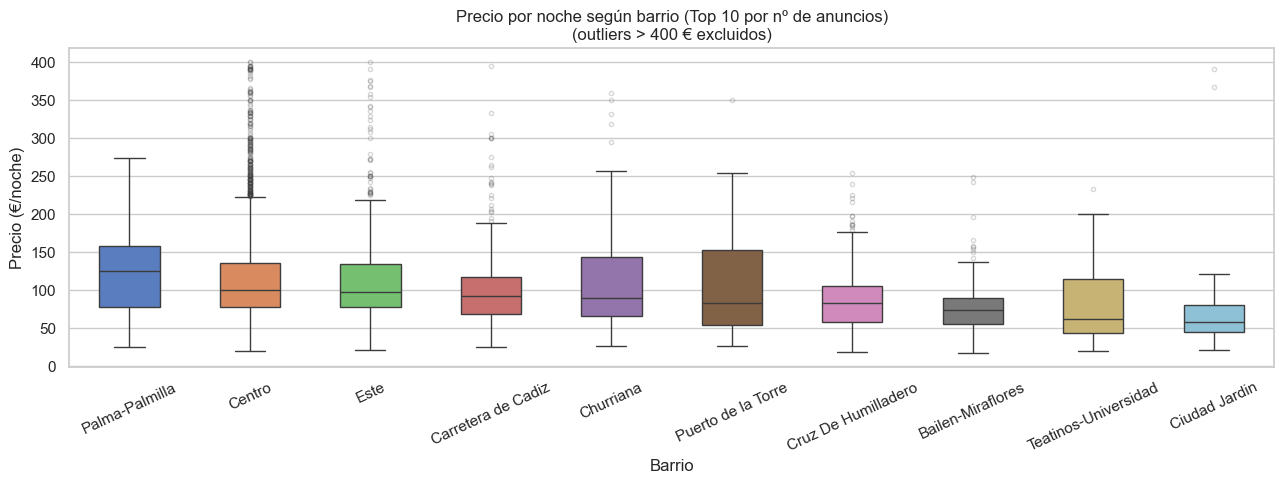

In [7]:
top10 = df["neighbourhood_cleansed"].value_counts().head(10).index
df_bar = df[df["neighbourhood_cleansed"].isin(top10) & df["price"].between(10, 400)].copy()
order_b = df_bar.groupby("neighbourhood_cleansed")["price"].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_bar, x="neighbourhood_cleansed", y="price", order=order_b,
            palette="muted", width=0.5, flierprops=dict(marker=".", alpha=0.2), ax=ax)

ax.set_title("Precio por noche según barrio (Top 10 por nº de anuncios)\n(outliers > 400 € excluidos)")
ax.set_xlabel("Barrio")
ax.set_ylabel("Precio (€/noche)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

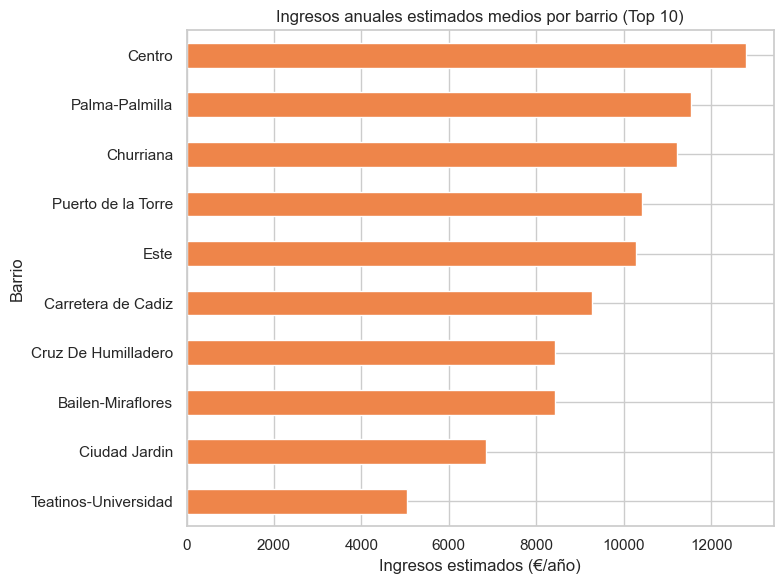

In [8]:
rev_barrio = (
    df[df["neighbourhood_cleansed"].isin(top10) & df["estimated_revenue_l365d"].between(1, 60000)]
    .groupby("neighbourhood_cleansed")["estimated_revenue_l365d"]
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
rev_barrio.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[1], edgecolor="white")

ax.set_title("Ingresos anuales estimados medios por barrio (Top 10)")
ax.set_xlabel("Ingresos estimados (€/año)")
ax.set_ylabel("Barrio")
plt.tight_layout()
plt.show()

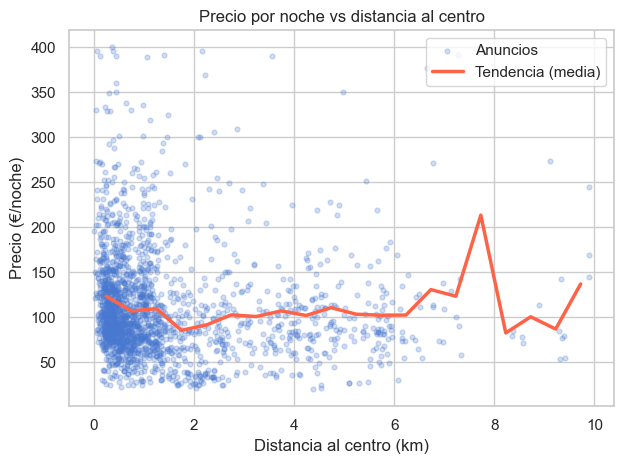

In [9]:
df_sc = df[df["price"].between(10, 400) & df["distancia_centro_km"].between(0, 10)].copy()
sample = df_sc.sample(2000, random_state=42)

fig, ax = plt.subplots()
ax.scatter(sample["distancia_centro_km"], sample["price"],
            alpha=0.25, s=12, label="Anuncios")

# Línea de tendencia (media por bins)
bins = pd.cut(df_sc["distancia_centro_km"], bins=20)
trend = df_sc.groupby(bins, observed=True)["price"].mean().reset_index()
trend["x"] = trend["distancia_centro_km"].apply(lambda b: b.mid)
ax.plot(trend["x"], trend["price"], color="tomato", linewidth=2.5, label="Tendencia (media)")

ax.set_title("Precio por noche vs distancia al centro")
ax.set_xlabel("Distancia al centro (km)")
ax.set_ylabel("Precio (€/noche)")
ax.legend()
plt.tight_layout()
plt.show()

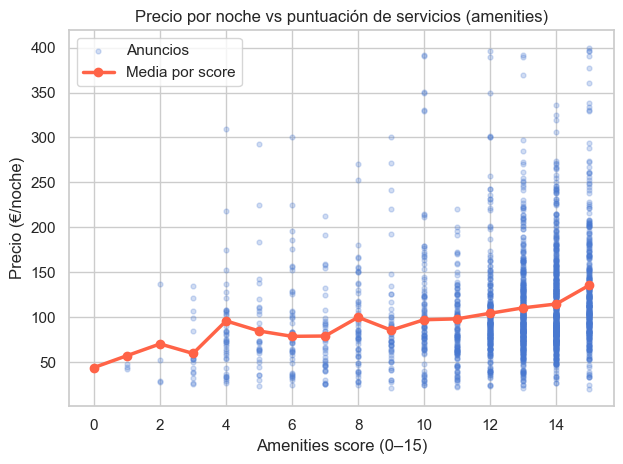

In [10]:
fig, ax = plt.subplots()
ax.scatter(sample["amenities_score"], sample["price"],
            alpha=0.25, s=12, label="Anuncios")

trend_a = df_sc.groupby("amenities_score")["price"].mean().reset_index().sort_values("amenities_score")
ax.plot(trend_a["amenities_score"], trend_a["price"],
        color="tomato", linewidth=2.5, marker="o", label="Media por score")

ax.set_title("Precio por noche vs puntuación de servicios (amenities)")
ax.set_xlabel("Amenities score (0–15)")
ax.set_ylabel("Precio (€/noche)")
ax.legend()
plt.tight_layout()
plt.show()

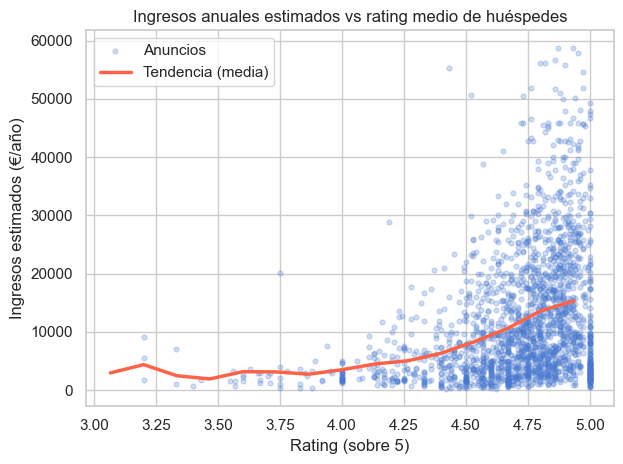

In [11]:
df_rv = df[df["estimated_revenue_l365d"].between(1, 60000) & df["review_scores_rating"].between(3, 5)].copy()
sample_r = df_rv.sample(2000, random_state=42)

fig, ax = plt.subplots()
ax.scatter(sample_r["review_scores_rating"], sample_r["estimated_revenue_l365d"],
            alpha=0.25, s=12, label="Anuncios")

trend_r = df_rv.groupby(
    pd.cut(df_rv["review_scores_rating"], bins=15), observed=True
)["estimated_revenue_l365d"].mean().reset_index()
trend_r["x"] = trend_r["review_scores_rating"].apply(lambda b: b.mid)
ax.plot(trend_r["x"], trend_r["estimated_revenue_l365d"],
        color="tomato", linewidth=2.5, label="Tendencia (media)")

ax.set_title("Ingresos anuales estimados vs rating medio de huéspedes")
ax.set_xlabel("Rating (sobre 5)")
ax.set_ylabel("Ingresos estimados (€/año)")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_24860\3784035011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sh, x="sh_label", y="price",


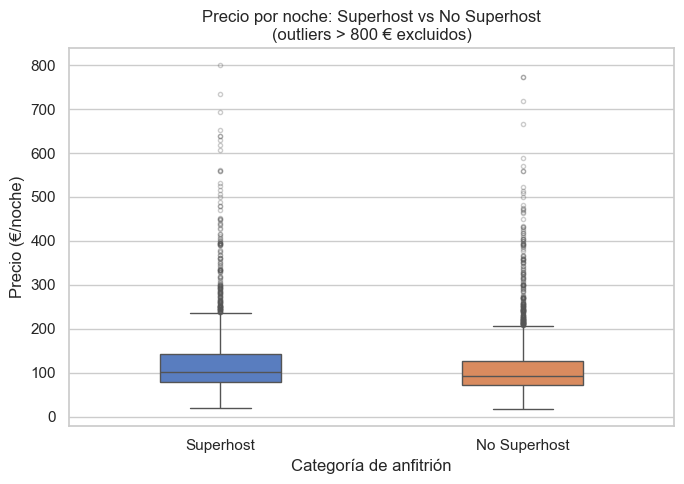

               count   mean   std   min   25%    50%    75%    max
sh_label                                                          
No Superhost  3314.0  109.4  68.0  18.0  72.0   93.0  126.0  774.0
Superhost     2289.0  123.4  80.1  20.0  79.0  103.0  142.0  800.0


In [12]:
df_sh = df[df["price"].between(10, 800)].copy()
df_sh["sh_label"] = df_sh["host_is_superhost"].map({1.0: "Superhost", 0.0: "No Superhost"})
df_sh = df_sh.dropna(subset=["sh_label"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_sh, x="sh_label", y="price",
            palette="muted", width=0.4,
            flierprops=dict(marker=".", alpha=0.3), ax=ax)

ax.set_title("Precio por noche: Superhost vs No Superhost\n(outliers > 800 € excluidos)")
ax.set_xlabel("Categoría de anfitrión")
ax.set_ylabel("Precio (€/noche)")
plt.tight_layout()
plt.show()

# Estadísticas comparativas
print(df_sh.groupby("sh_label")["price"].describe().round(1))

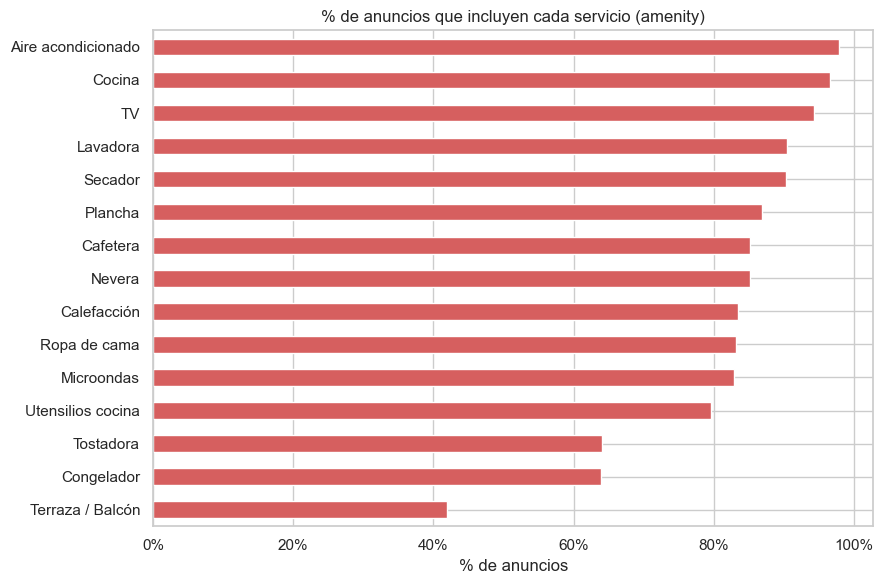

In [13]:
amenity_cols = [
    "has_kitchen", "has_hair_dryer", "has_iron", "has_bed_linens",
    "has_microwave", "has_refrigerator", "has_cooking_basics", "has_tv",
    "has_air_conditioning", "has_washer", "has_toaster", "has_heating",
    "has_freezer", "has_coffee_maker", "has_balcony_or_terrace"
]
amenity_labels = {
    "has_kitchen": "Cocina", "has_hair_dryer": "Secador", "has_iron": "Plancha",
    "has_bed_linens": "Ropa de cama", "has_microwave": "Microondas",
    "has_refrigerator": "Nevera", "has_cooking_basics": "Utensilios cocina",
    "has_tv": "TV", "has_air_conditioning": "Aire acondicionado",
    "has_washer": "Lavadora", "has_toaster": "Tostadora",
    "has_heating": "Calefacción", "has_freezer": "Congelador",
    "has_coffee_maker": "Cafetera", "has_balcony_or_terrace": "Terraza / Balcón"
}

amenity_pct = (df[amenity_cols].mean() * 100).rename(amenity_labels).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
amenity_pct.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[3], edgecolor="white")

ax.set_title("% de anuncios que incluyen cada servicio (amenity)")
ax.set_xlabel("% de anuncios")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()